# JEB FEM Dataset Pipeline

## Background

The **SimJEB** dataset contains ~400 real jet engine bracket (JEB) designs that have been **physically tested and verified** — their structural performance (displacement, stress, mass) is known ground truth. These brackets are modeled in OptiStruct `.fem` format using a tetrahedral mesh with the material properties of **Ti-6Al-4V** titanium alloy.

## Why We Need Synthesis

~1,000 samples is not enough to train a machine learning model that can **predict the structural response of new, unseen bracket geometries**. To generalize well, the model needs to see a much larger and more diverse set of examples.

Since we cannot physically manufacture and test thousands of new brackets, we **synthesize** new ones by applying controlled geometric transformations to the existing verified designs. Each synthetic variant:
- Still uses the same boundary conditions (bolt hole locations, pin interface, SPCs)
- Has a slightly different geometry → different structural response
- Is simulated with our FEA solver to produce its labels

## Pipeline Overview

```
Existing .fem files  →  Read & Parse  →  Visualize  →  Synthesize  →  Simulate  →  CSV Dataset
     (~1,000)             (Section 1)    (Section 2)   (Section 3)    (Section 3)
```

---

## Setup: Install Dependencies

In [13]:
%pip install --upgrade --force-reinstall "numpy<2" scipy pyNastran scikit-fem matplotlib python-dateutil

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached pyNastran-1.4.1-py3-none-any.whl.metadata (22 kB)
  Using cached scikit_fem-12.0.1-py3-none-any.whl.metadata (36 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached cpylog-1.6.0-py2.py3-none-any.whl.metadata (993 bytes)
  Using cached docopt_ng-0.9.0-py3-none-any.whl.metadata (13 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.m

## Imports

In [14]:
import numpy as np
import os
import csv
import re
import json
import glob
import tempfile
from collections import defaultdict
from copy import deepcopy

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from pyNastran.bdf.bdf import BDF
from skfem import MeshTet, Basis, ElementVector, ElementTetP1, asm
from skfem.models.elasticity import linear_elasticity
from scipy.sparse.linalg import spsolve

## Material Properties & Load Cases

All JEB designs in SimJEB are made from **Ti-6Al-4V** titanium alloy. The four load cases replicate the GE bracket challenge conditions.

In [15]:
# =============================================================================
# MATERIAL PROPERTIES  —  Ti-6Al-4V (per SimJEB specification)
# =============================================================================
E   = 113.8e3   # Young's modulus  [MPa]
nu  = 0.342     # Poisson's ratio  [-]
rho = 4.47e-3   # Density          [g/mm³]

# Lamé parameters used by the linear elasticity solver
lam = E * nu / ((1 + nu) * (1 - 2 * nu))
mu  = E / (2 * (1 + nu))

# =============================================================================
# UNIT CONVERSIONS  —  GE challenge uses lbf / lb·in; solver uses N / N·mm
# =============================================================================
LBF_TO_N    = 4.44822
LBIN_TO_NMM = 4.44822 * 25.4   # ≈ 112.985

# =============================================================================
# LOAD CASES  —  four structural scenarios from the GE bracket challenge
# =============================================================================
LOAD_CASES = {
    # Pure vertical uplift
    "vertical": {
        "force": np.array([0.0, 0.0, 8000.0 * LBF_TO_N]),
        "type": "force"
    },
    # Pure side load
    "horizontal": {
        "force": np.array([8500.0 * LBF_TO_N, 0.0, 0.0]),
        "type": "force"
    },
    # Combined load at 42° from vertical
    "diagonal": {
        "force": np.array([
            -42300.0 * np.sin(np.radians(42)),
             0.0,
             42300.0 * np.cos(np.radians(42))
        ]),
        "type": "force"
    },
    # Pure torsion about the pin axis (−Z)
    "torsion": {
        "moment": 5000.0 * LBIN_TO_NMM,
        "axis":   np.array([0.0, 0.0, -1.0]),
        "type":   "moment"
    },
}

---
# Section 1 — Reading JEB Data

OptiStruct `.fem` files contain:
- **GRID** cards — node coordinates
- **CTETRA** cards — tetrahedral elements (the solid mesh)
- **RBE2** cards — rigid bolt-hole connections (these define the **fixed** boundary condition)
- **RBE3** cards — pin interface interpolation elements (these define the **load application** region)
- **SPC** cards — single-point constraints (additional fixtures)

Reading all of these correctly is essential: the RBE/SPC data tells the FEA solver *where* to fix the model and *where* to apply the loads.

In [16]:
# =============================================================================
# FEM FILE PARSING
# =============================================================================

def read_fem_with_rbe(fem_file):
    """Read an OptiStruct .fem file and extract RBE2, RBE3, and SPC entries."""
    print(f"Reading: {fem_file}")

    with open(fem_file, 'r') as f:
        lines = f.readlines()

    rbe2_lines, rbe3_lines, spc_lines = [], [], []
    i = 0
    while i < len(lines):
        line = lines[i]

        if line.startswith('RBE2'):
            entry = line
            i += 1
            while i < len(lines) and (lines[i].startswith('+') or lines[i].startswith('        ')):
                entry += lines[i]
                i += 1
            rbe2_lines.append(entry)
            continue

        elif line.startswith('RBE3'):
            entry = line
            i += 1
            while i < len(lines) and (lines[i].startswith('+') or lines[i].startswith('        ')):
                entry += lines[i]
                i += 1
            rbe3_lines.append(entry)
            continue

        elif line.startswith('SPC'):
            spc_lines.append(line)

        i += 1

    print(f"  RBE2 (bolt holes): {len(rbe2_lines)}")
    print(f"  RBE3 (pin interface): {len(rbe3_lines)}")
    print(f"  SPC constraints: {len(spc_lines)}")
    return rbe2_lines, rbe3_lines, spc_lines


def parse_rbe2(rbe2_lines):
    """Parse RBE2 entries into structured dicts (bolt-hole rigid connections)."""
    elements = []
    for entry in rbe2_lines:
        clean = entry.replace('\n', ' ').replace('+', ' ')
        parts = clean.split()
        if len(parts) < 4:
            continue
        eid, gn, cm = int(parts[1]), int(parts[2]), parts[3]
        dependent_nodes = []
        for p in parts[4:]:
            try:
                dependent_nodes.append(int(p))
            except ValueError:
                continue
        elements.append({'eid': eid, 'center_node': gn, 'dofs': cm, 'dependent_nodes': dependent_nodes})
    return elements


def parse_rbe3(rbe3_lines):
    """Parse RBE3 entries into structured dicts (pin interface interpolation)."""
    elements = []
    for entry in rbe3_lines:
        clean = entry.replace('\n', ' ').replace('+', ' ')
        parts = clean.split()
        if len(parts) < 6:
            continue
        eid = int(parts[1])
        refgrid = None
        independent_nodes = []
        for p in parts[2:]:
            try:
                val = int(p)
                if refgrid is None:
                    refgrid = val
                else:
                    independent_nodes.append(val)
            except ValueError:
                pass
        elements.append({'eid': eid, 'ref_node': refgrid, 'independent_nodes': independent_nodes[1:]})
    return elements


def parse_spc(spc_lines):
    """Parse SPC (Single Point Constraint) entries."""
    constraints = []
    for line in spc_lines:
        parts = line.split()
        if len(parts) >= 4:
            constraints.append({'sid': int(parts[1]), 'node': int(parts[2]), 'dofs': parts[3]})
    return constraints


def read_optistruct_fem(fem_file):
    """Load an OptiStruct .fem file via pyNastran (strips non-BDF header cards)."""
    with open(fem_file, 'r') as f:
        lines = f.readlines()

    # Find where the BULK DATA section starts
    bulk_start = next((i + 1 for i, l in enumerate(lines) if 'BEGIN BULK' in l.upper()), 0)
    bulk_lines = lines[bulk_start:]

    # Strip OptiStruct-specific cards that pyNastran doesn't understand
    skip = ['ENDDATA', 'HMNAME', 'HWCOLOR']
    filtered = [l for l in bulk_lines if not any(l.strip().upper().startswith(s) for s in skip)]

    with tempfile.NamedTemporaryFile(mode='w', suffix='.bdf', delete=False) as tmp:
        tmp.writelines(filtered)
        tmp_name = tmp.name

    model = BDF(debug=False)
    model.read_bdf(tmp_name, punch=True, xref=False)
    os.remove(tmp_name)
    return model


def bdf_to_arrays(bdf):
    """
    Convert a pyNastran BDF model to numpy arrays for the FEA solver.
    Excludes virtual RBE centre nodes (they have no element connectivity).
    """
    all_node_ids = list(bdf.nodes.keys())

    # Only keep nodes that actually appear in CTETRA elements
    nodes_in_tets = set()
    for e in bdf.elements.values():
        if e.type == 'CTETRA':
            nodes_in_tets.update(e.node_ids[:4])

    virtual_node_ids = set(all_node_ids) - nodes_in_tets
    print(f"  Total nodes in file : {len(all_node_ids)}")
    print(f"  Mesh nodes (in tets): {len(nodes_in_tets)}")
    print(f"  Virtual/RBE nodes   : {len(virtual_node_ids)}")

    mesh_node_ids = sorted(nodes_in_tets)
    coords    = np.array([bdf.nodes[nid].get_position() for nid in mesh_node_ids])
    nid_to_idx = {nid: i for i, nid in enumerate(mesh_node_ids)}

    tets = []
    for e in bdf.elements.values():
        if e.type == 'CTETRA':
            tets.append([nid_to_idx[n] for n in e.node_ids[:4]])

    return coords, np.array(tets, dtype=np.int32), nid_to_idx, mesh_node_ids, virtual_node_ids


def get_boundary_faces_and_nodes(tets):
    """Extract the outer surface of a tetrahedral mesh (faces shared by only one element)."""
    face_count = defaultdict(int)
    face_to_nodes = {}
    for tet in tets:
        faces = [(tet[0],tet[1],tet[2]), (tet[0],tet[1],tet[3]),
                 (tet[0],tet[2],tet[3]), (tet[1],tet[2],tet[3])]
        for face in faces:
            key = tuple(sorted(face))
            face_count[key] += 1
            face_to_nodes[key] = face
    boundary_faces = [face_to_nodes[k] for k, c in face_count.items() if c == 1]
    boundary_nodes = set(n for face in boundary_faces for n in face)
    return boundary_faces, np.array(list(boundary_nodes))

In [17]:
# =============================================================================
# FEA SOLVER  —  linear elasticity with scikit-fem
# =============================================================================

def solve_fea(coords, tets, fixed_node_indices, load_node_indices, load_case, load_centroid=None):
    """
    Assemble and solve the linear elasticity system K·u = f.

    Returns
    -------
    ndarray, shape (N, 3)  —  displacement at every mesh node [mm]
    """
    mesh    = MeshTet(coords.T.copy(), tets.T.copy())
    element = ElementVector(ElementTetP1())
    basis   = Basis(mesh, element)

    K = asm(linear_elasticity(lam, mu), basis)
    f = np.zeros(basis.N)

    if len(load_node_indices) == 0:
        raise ValueError("No load nodes found — check RBE3 parsing.")

    # --- Apply load ---
    if load_case["type"] == "force":
        force_per_node = load_case["force"] / len(load_node_indices)
        for n in load_node_indices:
            f[n*3:n*3+3] += force_per_node

    elif load_case["type"] == "moment":
        moment_mag  = load_case["moment"]
        moment_axis = load_case.get("axis", np.array([0.0, 0.0, -1.0]))
        if load_centroid is None:
            load_centroid = coords[load_node_indices].mean(axis=0)

        # Torsion about Z axis (most common case)
        if abs(moment_axis[2]) > 0.5:
            total_lever_sq = sum(
                np.sum((coords[n][:2] - load_centroid[:2])**2)
                for n in load_node_indices
            )
            for n in load_node_indices:
                r = coords[n] - load_centroid
                lever = np.sqrt(r[0]**2 + r[1]**2)
                if lever > 1e-6 and total_lever_sq > 1e-6:
                    tangent = np.array([r[1], -r[0], 0.0])
                    t_norm = np.linalg.norm(tangent)
                    if t_norm > 1e-6:
                        tangent /= t_norm
                        force_mag = moment_mag * lever / total_lever_sq
                        f[n*3:n*3+3] += tangent * force_mag * (-moment_axis[2])

        # Torsion about Y axis
        elif abs(moment_axis[1]) > 0.5:
            total_lever_sq = sum(
                r[0]**2 + r[2]**2
                for n in load_node_indices
                for r in [coords[n] - load_centroid]
            )
            for n in load_node_indices:
                r = coords[n] - load_centroid
                lever = np.sqrt(r[0]**2 + r[2]**2)
                if lever > 1e-6 and total_lever_sq > 1e-6:
                    tangent = np.array([-r[2], 0.0, r[0]])
                    t_norm = np.linalg.norm(tangent)
                    if t_norm > 1e-6:
                        tangent /= t_norm
                        force_mag = moment_mag * lever / total_lever_sq
                        f[n*3:n*3+3] += tangent * force_mag * moment_axis[1]

    # --- Apply boundary conditions ---
    fixed_dofs = np.array([dof for n in fixed_node_indices for dof in [n*3, n*3+1, n*3+2]], dtype=np.int64)
    free_dofs  = np.setdiff1d(np.arange(basis.N), fixed_dofs)

    u_free = spsolve(K[free_dofs][:, free_dofs].tocsr(), f[free_dofs])
    u = np.zeros(basis.N)
    u[free_dofs] = u_free

    return u.reshape((-1, 3))

In [18]:
# =============================================================================
# VON MISES STRESS  —  nodal averaging with singularity exclusion
# =============================================================================

def compute_von_mises_stress(coords, tets, displacements, E, nu, fixed_node_indices=None):
    """
    Compute nodal von Mises stress via the constitutive relation σ = D·B·u.

    Elements touching the fixed (clamped) nodes are excluded to avoid stress
    singularities at the bolt holes — consistent with commercial FEA practice.

    Returns
    -------
    float  —  peak von Mises stress away from constraints [MPa]
    """
    num_nodes = len(coords)
    fixed_set = set(fixed_node_indices) if fixed_node_indices is not None else set()

    # 3-D isotropic constitutive matrix D  [6×6]
    fac = E / ((1 + nu) * (1 - 2*nu))
    D = fac * np.array([
        [1-nu,   nu,    nu,          0,          0,          0],
        [  nu, 1-nu,    nu,          0,          0,          0],
        [  nu,   nu,  1-nu,          0,          0,          0],
        [   0,    0,     0, (1-2*nu)/2,          0,          0],
        [   0,    0,     0,          0, (1-2*nu)/2,          0],
        [   0,    0,     0,          0,          0, (1-2*nu)/2]
    ])

    nodal_stress_sum = np.zeros((num_nodes, 6))
    nodal_count      = np.zeros(num_nodes)
    nodes_near_bc    = set()

    for tet in tets:
        if any(n in fixed_set for n in tet):
            nodes_near_bc.update(tet)
            continue

        x = coords[tet]          # (4,3)
        u = displacements[tet]   # (4,3)

        J    = np.array([x[1]-x[0], x[2]-x[0], x[3]-x[0]]).T
        detJ = np.linalg.det(J)
        if abs(detJ) < 1e-12:
            continue

        Jinv  = np.linalg.inv(J)
        dN_xi = np.array([[-1,-1,-1],[1,0,0],[0,1,0],[0,0,1]])
        dN_dx = dN_xi @ Jinv.T   # (4,3)

        # Strain-displacement matrix B  [6×12]
        B = np.zeros((6, 12))
        for j in range(4):
            B[0, 3*j]   = dN_dx[j,0]              # εxx
            B[1, 3*j+1] = dN_dx[j,1]              # εyy
            B[2, 3*j+2] = dN_dx[j,2]              # εzz
            B[3, 3*j]   = dN_dx[j,1]; B[3, 3*j+1] = dN_dx[j,0]  # γxy
            B[4, 3*j+1] = dN_dx[j,2]; B[4, 3*j+2] = dN_dx[j,1]  # γyz
            B[5, 3*j]   = dN_dx[j,2]; B[5, 3*j+2] = dN_dx[j,0]  # γxz

        stress = D @ (B @ u.flatten())   # (6,)
        for n in tet:
            nodal_stress_sum[n] += stress
            nodal_count[n]      += 1

    nodal_count[nodal_count == 0] = 1
    s = nodal_stress_sum / nodal_count[:, None]

    von_mises = np.sqrt(
        0.5 * ((s[:,0]-s[:,1])**2 + (s[:,1]-s[:,2])**2 + (s[:,2]-s[:,0])**2) +
        3.0 * (s[:,3]**2 + s[:,4]**2 + s[:,5]**2)
    )

    # Mask: exclude fixed nodes and their neighbouring elements
    mask = np.ones(num_nodes, dtype=bool)
    for idx in fixed_set | nodes_near_bc:
        if idx < num_nodes:
            mask[idx] = False
    mask[nodal_count.flatten() <= 0] = False
    mask[von_mises == 0] = False

    print(f"  Stress: {mask.sum()} nodes used, {len(fixed_set)+len(nodes_near_bc)} excluded")
    return float(np.max(von_mises[mask])) if mask.any() else float(np.max(von_mises[von_mises > 0]))

In [19]:
# =============================================================================
# FEATURE EXTRACTION  —  runs all 4 load cases and returns a feature dict
# =============================================================================

def extract_features_from_fem(fem_file):
    """
    Parse a .fem file, run FEA under all 4 load cases, and return a flat
    feature dictionary suitable for writing to CSV.

    Returns
    -------
    dict  —  geometry + per-load-case displacement & stress features
    """
    print(f"\n{'='*70}")
    print(f"Processing: {os.path.basename(fem_file)}")
    print(f"{'='*70}")

    # --- Parse boundary conditions ---
    rbe2_lines, rbe3_lines, spc_lines = read_fem_with_rbe(fem_file)
    rbe2_elements   = parse_rbe2(rbe2_lines)
    rbe3_elements   = parse_rbe3(rbe3_lines)
    spc_constraints = parse_spc(spc_lines)

    # --- Load mesh ---
    model = read_optistruct_fem(fem_file)
    model.cross_reference()
    coords, tets, nid_to_idx, node_ids, virtual_node_ids = bdf_to_arrays(model)
    print(f"  Mesh nodes: {len(coords)},  Elements: {len(tets)}")

    # --- Geometry features ---
    boundary_faces, boundary_nodes = get_boundary_faces_and_nodes(tets)
    volume = sum(e.Volume() for e in model.elements.values() if e.type == 'CTETRA')
    mass_g = rho * volume
    print(f"  Volume: {volume:.2f} mm³  |  Mass: {mass_g/1000:.4f} kg")

    # --- Map RBE/SPC to mesh node indices ---
    fixed_node_ids = set()
    for rbe in rbe2_elements:
        for nid in rbe['dependent_nodes']:
            if nid in nid_to_idx:
                fixed_node_ids.add(nid)
    for spc in spc_constraints:
        if spc['node'] in nid_to_idx:
            fixed_node_ids.add(spc['node'])

    load_node_ids = set()
    load_ref_node = None
    for rbe in rbe3_elements:
        for nid in rbe['independent_nodes']:
            if nid in nid_to_idx:
                load_node_ids.add(nid)
        load_ref_node = rbe['ref_node']

    fixed_node_indices = [nid_to_idx[nid] for nid in fixed_node_ids]
    load_node_indices  = [nid_to_idx[nid] for nid in load_node_ids]
    print(f"  Fixed nodes: {len(fixed_node_indices)},  Load nodes: {len(load_node_indices)}")

    # Load centroid (prefer RBE3 reference node if it exists in the model)
    if load_ref_node and load_ref_node in model.nodes:
        load_centroid = model.nodes[load_ref_node].get_position()
    elif load_node_indices:
        load_centroid = coords[load_node_indices].mean(axis=0)
    else:
        load_centroid = None

    # --- Run FEA for each load case ---
    print(f"\n  Running FEA...")
    results = {}

    for case_name, load_case in LOAD_CASES.items():
        print(f"    [{case_name}] ", end="")
        try:
            disp = solve_fea(coords, tets, fixed_node_indices, load_node_indices,
                             load_case, load_centroid)
            mag  = np.linalg.norm(disp, axis=1)

            if case_name == "horizontal":
                xd = abs(float(np.min(disp[:,0])))
                yd = abs(float(np.min(disp[:,1])))
                zd = abs(float(np.min(disp[:,2])))
            else:
                xd = float(np.max(disp[:,0]))
                yd = float(np.max(disp[:,1]))
                zd = float(np.max(disp[:,2]))
            md = float(np.max(mag))

            vm = compute_von_mises_stress(coords, tets, disp, E, nu, fixed_node_indices)
            print(f"max_disp={md:.4f} mm, max_VM={vm:.1f} MPa")

            results[case_name] = {'xdisp': xd, 'ydisp': yd, 'zdisp': zd, 'magdisp': md, 'von_mises': vm}

        except Exception as e:
            print(f"ERROR: {e}")
            results[case_name] = None

    # --- Build feature dict ---
    def get(case, key):
        return results[case][key] if results.get(case) else None

    features = {
        'id':           os.path.splitext(os.path.basename(fem_file))[0],
        'volume':       float(volume),
        'mass_g':       float(mass_g),
        'mass_kg':      float(mass_g / 1000),
        'num_vertices': int(len(boundary_nodes)),
        'num_faces':    int(len(boundary_faces)),
        'num_tets':     int(len(tets)),

        'max_ver_xdisp':  get('vertical',   'xdisp'),   'max_ver_ydisp':  get('vertical',   'ydisp'),
        'max_ver_zdisp':  get('vertical',   'zdisp'),   'max_ver_magdisp':get('vertical',   'magdisp'),
        'max_ver_stress': get('vertical',   'von_mises'),

        'max_hor_xdisp':  get('horizontal', 'xdisp'),   'max_hor_ydisp':  get('horizontal', 'ydisp'),
        'max_hor_zdisp':  get('horizontal', 'zdisp'),   'max_hor_magdisp':get('horizontal', 'magdisp'),
        'max_hor_stress': get('horizontal', 'von_mises'),

        'max_dia_xdisp':  get('diagonal',   'xdisp'),   'max_dia_ydisp':  get('diagonal',   'ydisp'),
        'max_dia_zdisp':  get('diagonal',   'zdisp'),   'max_dia_magdisp':get('diagonal',   'magdisp'),
        'max_dia_stress': get('diagonal',   'von_mises'),

        'max_tor_xdisp':  get('torsion',    'xdisp'),   'max_tor_ydisp':  get('torsion',    'ydisp'),
        'max_tor_zdisp':  get('torsion',    'zdisp'),   'max_tor_magdisp':get('torsion',    'magdisp'),
        'max_tor_stress': get('torsion',    'von_mises'),
    }
    return features

In [22]:
# ---- Example: extract features from one verified JEB file ----
BASE_DIR  = 'data/raw'
FEM_FILE = os.path.join(BASE_DIR, '225.fem')
features = extract_features_from_fem(FEM_FILE)

print("\nExtracted features:")
for k, v in features.items():
    print(f"  {k:<22} {v}")


Processing: 225.fem
Reading: data/raw/225.fem
  RBE2 (bolt holes): 4
  RBE3 (pin interface): 1
  SPC constraints: 4
  Total nodes in file : 44126
  Mesh nodes (in tets): 44121
  Virtual/RBE nodes   : 5
  Mesh nodes: 44121,  Elements: 215219


KeyboardInterrupt: 

---
# Section 2 — Visualization

Before generating synthetic data it is useful to visually inspect the mesh to confirm:
1. The geometry parsed correctly (no missing nodes / inverted elements)
2. Augmented variants look like plausible bracket shapes (not distorted beyond engineering sense)

In [23]:
# =============================================================================
# MESH READING FOR VISUALIZATION
# =============================================================================

def read_fem_nodes_and_elements(fem_file):
    """Lightweight parser — reads GRID, CTETRA, CTRIA3, CQUAD4 for plotting only."""
    nodes, elements = {}, []

    with open(fem_file, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i]

        # GRID nodes
        if line.startswith('GRID') and not line.startswith('GRID*'):
            try:
                if ',' in line:
                    p = line.split(',')
                    nid = int(p[1]); x = float(p[3]); y = float(p[4])
                    z   = float(p[5]) if len(p) > 5 and p[5].strip() else 0.0
                else:
                    nid = int(line[8:16])
                    x   = float(line[24:32]) if line[24:32].strip() else 0.0
                    y   = float(line[32:40]) if len(line) > 32 and line[32:40].strip() else 0.0
                    z   = float(line[40:48]) if len(line) > 40 and line[40:48].strip() else 0.0
                nodes[nid] = np.array([x, y, z])
            except (ValueError, IndexError):
                pass

        # CTETRA — solid tet
        elif line.startswith('CTETRA'):
            try:
                if ',' in line:
                    p = line.split(',')
                    ns = [int(p[k]) for k in range(3, 7)]
                else:
                    ns = [int(line[24+8*k:32+8*k]) for k in range(4) if line[24+8*k:32+8*k].strip()]
                elements.append({'type': 'CTETRA', 'nodes': ns})
            except (ValueError, IndexError):
                pass

        # CTRIA3 — triangular shell
        elif line.startswith('CTRIA3'):
            try:
                if ',' in line:
                    p = line.split(',')
                    elements.append({'type': 'CTRIA3', 'nodes': [int(p[3]), int(p[4]), int(p[5])]})
                else:
                    elements.append({'type': 'CTRIA3', 'nodes': [int(line[24:32]), int(line[32:40]), int(line[40:48])]})
            except (ValueError, IndexError):
                pass

        # CQUAD4 — quad shell
        elif line.startswith('CQUAD4'):
            try:
                if ',' in line:
                    p = line.split(',')
                    elements.append({'type': 'CQUAD4', 'nodes': [int(p[3]), int(p[4]), int(p[5]), int(p[6])]})
                else:
                    elements.append({'type': 'CQUAD4', 'nodes': [int(line[24:32]), int(line[32:40]),
                                                                  int(line[40:48]), int(line[48:56])]})
            except (ValueError, IndexError):
                pass

        i += 1
    return nodes, elements


def get_surface_faces_from_tetra(nodes, elements):
    """Extract the visible surface triangles from a tetrahedral solid mesh."""
    face_count = {}
    for elem in elements:
        if elem['type'] == 'CTETRA':
            n = elem['nodes']
            for face in [(n[0],n[1],n[2]), (n[0],n[1],n[3]),
                         (n[0],n[2],n[3]), (n[1],n[2],n[3])]:
                key = tuple(sorted(face))
                face_count[key] = face_count.get(key, 0) + 1
    return [f for f, c in face_count.items() if c == 1]

In [ ]:
# =============================================================================
# VISUALIZATION HELPERS
# =============================================================================

def visualize_fem(fem_file, ax, title, color='steelblue', alpha=0.7):
    """Plot a single FEM surface mesh on a given 3-D matplotlib axis."""
    nodes, elements = read_fem_nodes_and_elements(fem_file)
    print(f"  {title}: {len(nodes)} nodes, {len(elements)} elements")
    if not nodes:
        return

    coords = np.array(list(nodes.values()))
    faces_to_plot = []

    tet_elems   = [e for e in elements if e['type'] == 'CTETRA']
    shell_elems = [e for e in elements if e['type'] in ['CTRIA3', 'CQUAD4']]

    if tet_elems:
        for face in get_surface_faces_from_tetra(nodes, tet_elems):
            try:
                faces_to_plot.append([nodes[nid] for nid in face])
            except KeyError:
                pass

    if shell_elems:
        for elem in shell_elems:
            try:
                faces_to_plot.append([nodes[nid] for nid in elem['nodes']])
            except KeyError:
                pass

    if not faces_to_plot:
        ax.scatter(coords[:,0], coords[:,1], coords[:,2], c=color, s=1, alpha=0.5)
    else:
        # Subsample if the mesh is very dense
        if len(faces_to_plot) > 10_000:
            idx = np.random.choice(len(faces_to_plot), 10_000, replace=False)
            faces_to_plot = [faces_to_plot[i] for i in idx]
        ax.add_collection3d(Poly3DCollection(faces_to_plot, alpha=alpha,
                                             facecolor=color, edgecolor='darkblue', linewidth=0.1))

    # Equal-aspect framing
    max_r = max(coords[:,k].max() - coords[:,k].min() for k in range(3)) / 2
    mid   = coords.mean(axis=0)
    for k, setter in enumerate([ax.set_xlim, ax.set_ylim, ax.set_zlim]):
        setter(mid[k] - max_r, mid[k] + max_r)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)


def compare_fem_files(fem_file1, fem_file2, save_path='fem_comparison.png'):
    """Plot two FEM files side-by-side for visual comparison."""
    fig = plt.figure(figsize=(16, 7))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')
    visualize_fem(fem_file1, ax1, os.path.basename(fem_file1), color='steelblue', alpha=0.6)
    visualize_fem(fem_file2, ax2, os.path.basename(fem_file2), color='coral',     alpha=0.6)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save_path}")


def visualize_single_fem(fem_file, save_path=None):
    """Show a FEM file from four orthographic views (3D, Top, Front, Side)."""
    views = [
        ('3D View',        221, 30,  45),
        ('Top (XY)',       222, 90,   0),
        ('Front (XZ)',     223,  0,   0),
        ('Side (YZ)',      224,  0,  90),
    ]
    fig = plt.figure(figsize=(16, 12))
    for title, pos, elev, azim in views:
        ax = fig.add_subplot(pos, projection='3d')
        visualize_fem(fem_file, ax, title, color='steelblue', alpha=0.6)
        ax.view_init(elev=elev, azim=azim)
    plt.suptitle(os.path.basename(fem_file), fontsize=14)
    plt.tight_layout()
    if save_path is None:
        save_path = os.path.splitext(fem_file)[0] + '_views.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save_path}")

  3D View: 39670 nodes, 215219 elements
  Top (XY): 39670 nodes, 215219 elements
  Front (XZ): 39670 nodes, 215219 elements
  Side (YZ): 39670 nodes, 215219 elements


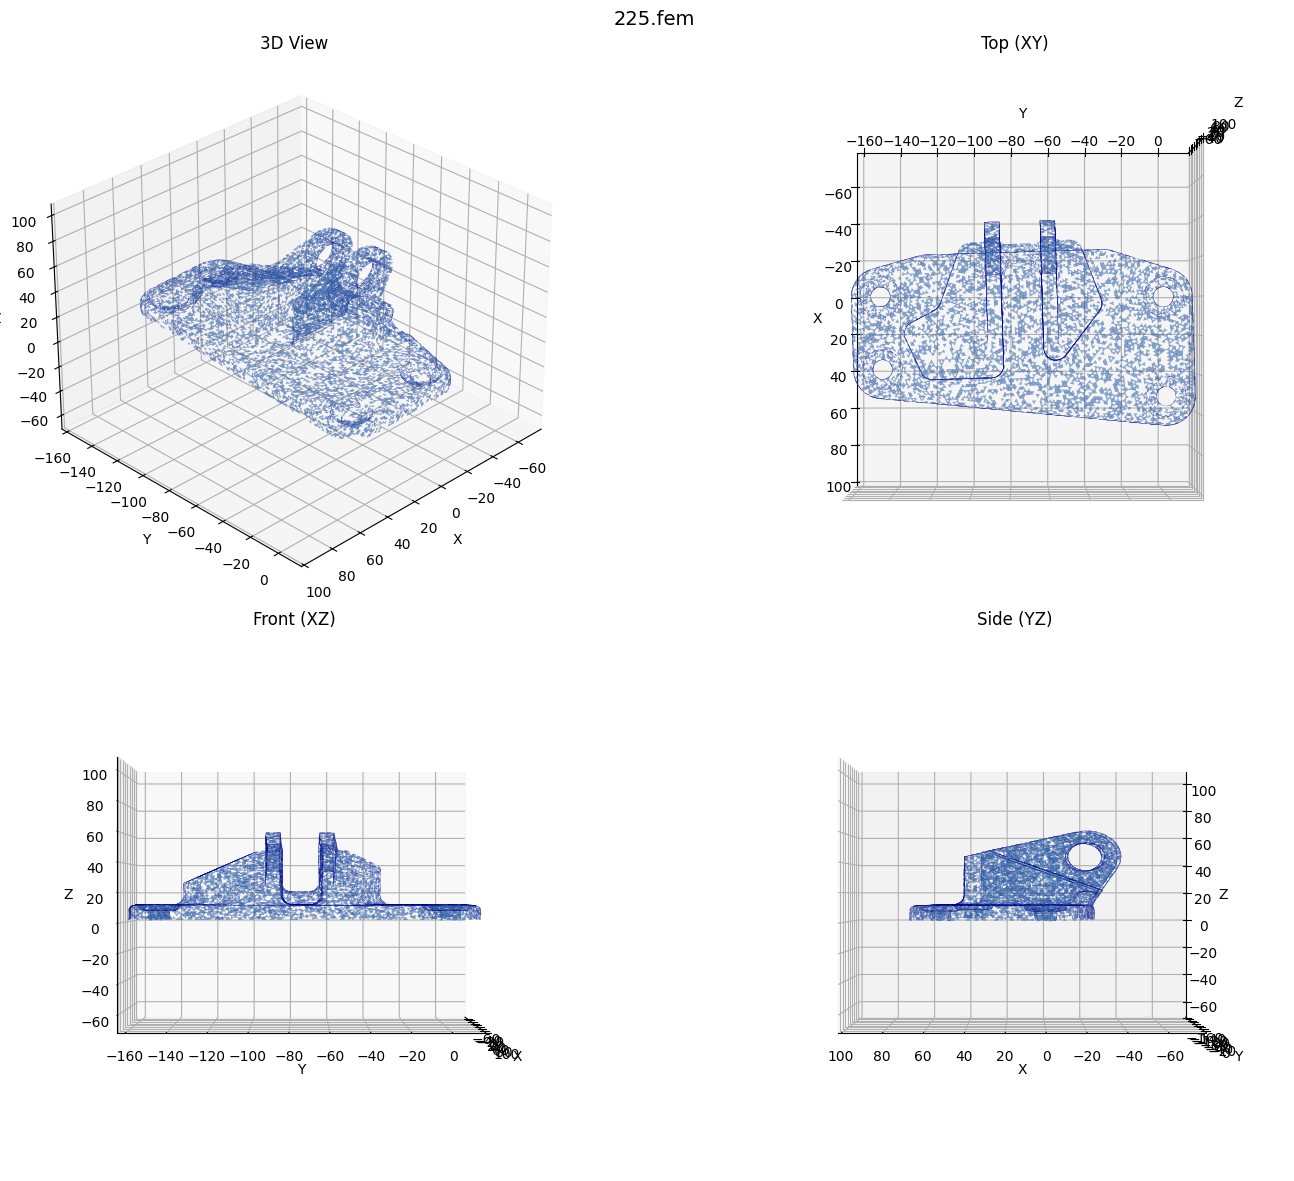

Saved → data/raw/225_views.png


In [24]:
# ---- Example: visualise original vs one augmented variant ----
BASE_DIR  = 'data/raw'
FEM_FILE_1 = os.path.join(BASE_DIR, '225.fem')
#FEM_FILE_2 = os.path.join(BASE_DIR, '8_ver_2.fem')

#compare_fem_files(FEM_FILE_1, FEM_FILE_2)
visualize_single_fem(FEM_FILE_1)

---
# Section 3 — Synthesis

## Why We Synthesize

The ~400 verified JEB designs are geometrically diverse but not diverse *enough* for an ML model to learn robust structure-performance mappings. We expand the dataset by applying small, physically plausible geometric perturbations to each existing design.

**Key constraint:** the boundary condition topology (bolt holes, pin interface) is preserved — we only move internal node coordinates. The resulting `.fem` files are valid OptiStruct inputs and can be simulated immediately.

## Synthesis Criteria

We apply six classes of geometric transformation:

| # | Name | What it does | Parameter range |
|---|------|-------------|----------------|
| 1 | **Uniform scaling** | Scales the entire bracket up or down from its centroid — simulates overall size variation | ±5% |
| 2 | **Non-uniform (axis) scaling** | Independently scales along X, Y, or Z — simulates aspect-ratio variation (longer, wider, thicker) | ±3% per axis |
| 3 | **Random node perturbation** | Adds small Gaussian noise to every node position — simulates manufacturing tolerances and mesh irregularity | 0.1 – 0.2% of bounding box |
| 4 | **Taper** | Linearly scales cross-sections along one axis — simulates tapered bracket flanges | 3% |
| 5 | **Shear** | Applies a shear deformation in the XY plane — shifts the bracket's load path angle | 2% |
| 6 | **Combined** | Stacks two transforms (e.g. scale + noise) — increases variety without doubling compute | — |

In [ ]:
# =============================================================================
# FEM AUGMENTOR  —  geometric transformations on OptiStruct .fem files
# =============================================================================

class FEMAugmentor:
    """
    Loads a .fem file, exposes augmentation methods, and writes modified
    .fem files that remain valid OptiStruct inputs.
    """

    def __init__(self, fem_file):
        self.fem_file       = fem_file
        self.original_lines = None
        self.node_lines     = {}   # line_index → (node_id, x, y, z, fmt [, cont_line_idx])
        self.node_coords    = {}   # node_id    → [x, y, z]
        self._load_fem()

    # ------------------------------------------------------------------
    # Loading
    # ------------------------------------------------------------------

    def _load_fem(self):
        with open(self.fem_file, 'r') as f:
            self.original_lines = f.readlines()

        i = 0
        while i < len(self.original_lines):
            line = self.original_lines[i]

            if line.startswith('GRID'):
                if ',' in line:
                    # Free-field (comma-separated) format
                    p = line.split(',')
                    if len(p) >= 5:
                        try:
                            nid = int(p[1].strip())
                            x   = float(p[3].strip()) if p[3].strip() else 0.0
                            y   = float(p[4].strip()) if p[4].strip() else 0.0
                            z   = float(p[5].strip()) if len(p) > 5 and p[5].strip() else 0.0
                            self.node_lines[i]    = (nid, x, y, z)
                            self.node_coords[nid] = [x, y, z]
                        except (ValueError, IndexError):
                            pass
                else:
                    try:
                        if line.startswith('GRID*'):
                            # Large-field (16-char) format — Z is on the continuation line
                            nid = int(line[8:24].strip())
                            x   = float(line[40:56].strip()) if line[40:56].strip() else 0.0
                            y   = float(line[56:72].strip()) if len(line) > 56 and line[56:72].strip() else 0.0
                            if i + 1 < len(self.original_lines):
                                cont = self.original_lines[i + 1]
                                if cont.startswith('*') or cont.startswith('+'):
                                    z = float(cont[8:24].strip()) if cont[8:24].strip() else 0.0
                                    self.node_lines[i]    = (nid, x, y, z, 'large', i + 1)
                                    self.node_coords[nid] = [x, y, z]
                                    i += 1
                        else:
                            # Standard fixed-field (8-char) format
                            nid = int(line[8:16].strip())
                            x   = float(line[24:32].strip()) if line[24:32].strip() else 0.0
                            y   = float(line[32:40].strip()) if len(line) > 32 and line[32:40].strip() else 0.0
                            z   = float(line[40:48].strip()) if len(line) > 40 and line[40:48].strip() else 0.0
                            self.node_lines[i]    = (nid, x, y, z, 'small')
                            self.node_coords[nid] = [x, y, z]
                    except (ValueError, IndexError):
                        pass
            i += 1

        coords_arr   = np.array(list(self.node_coords.values()))
        self.centroid = coords_arr.mean(axis=0)
        self.bbox_min = coords_arr.min(axis=0)
        self.bbox_max = coords_arr.max(axis=0)
        self.bbox_size = self.bbox_max - self.bbox_min
        print(f"Loaded {len(self.node_coords)} nodes | bbox size: {self.bbox_size.round(1)}")

    # ------------------------------------------------------------------
    # Utilities
    # ------------------------------------------------------------------

    def _fmt(self, value, width=8):
        """Format a float to exactly `width` characters in Nastran style."""
        if abs(value) < 1e-15:
            return '0.'.rjust(width)
        for dec in [4, 3, 2, 1, 0]:
            s = f'{value:.{dec}f}'
            if len(s) <= width:
                return s.rjust(width)
        # Nastran short-scientific fallback: e.g.  1.23-4
        exp = int(np.floor(np.log10(abs(value))))
        mant = value / 10**exp
        for dec in [3, 2, 1, 0]:
            s = f'{mant:.{dec}f}+{exp}' if exp >= 0 else f'{mant:.{dec}f}{exp}'
            if len(s) <= width:
                return s.rjust(width)
        return f'{value:.1e}'[:width].rjust(width)

    def _apply(self, transform_func):
        """Apply a (node_id, x, y, z) → (x', y', z') function to all nodes."""
        return {nid: list(transform_func(nid, *xyz)) for nid, xyz in self.node_coords.items()}

    def write_fem(self, new_coords, output_file):
        """Write a new .fem file with updated node coordinates, preserving all other cards."""
        new_lines = list(self.original_lines)

        for line_idx, node_info in self.node_lines.items():
            if len(node_info) == 6:
                nid, _, _, _, fmt, cont_idx = node_info
            elif len(node_info) == 5:
                nid, _, _, _, fmt = node_info; cont_idx = None
            else:
                nid, _, _, _ = node_info; fmt = 'small'; cont_idx = None

            if nid not in new_coords:
                continue
            nx, ny, nz = new_coords[nid]
            orig = self.original_lines[line_idx]

            if fmt == 'large':
                new_line = orig[:40] + f'{nx:16.8f}{ny:16.8f}'
                new_line += orig[72:] if len(orig) > 72 else '\n'
                new_lines[line_idx] = new_line
                if cont_idx is not None:
                    cont = self.original_lines[cont_idx]
                    new_lines[cont_idx] = cont[:8] + f'{nz:16.8f}' + (cont[24:] if len(cont) > 24 else '\n')
            else:
                new_line = orig[:24] + self._fmt(nx) + self._fmt(ny) + self._fmt(nz)
                new_line += orig[48:].rstrip('\n') + '\n' if len(orig) > 48 else '\n'
                new_lines[line_idx] = new_line

        with open(output_file, 'w') as f:
            f.writelines(new_lines)
        print(f"  Written → {output_file}")
        return output_file

    # ------------------------------------------------------------------
    # Synthesis criterion 1 — Uniform scaling
    # ------------------------------------------------------------------
    def augment_uniform_scale(self, factor):
        """Scale the whole model by `factor` about its centroid."""
        c = self.centroid
        return self._apply(lambda nid, x, y, z: (
            c[0] + (x - c[0]) * factor,
            c[1] + (y - c[1]) * factor,
            c[2] + (z - c[2]) * factor
        ))

    # ------------------------------------------------------------------
    # Synthesis criterion 2 — Non-uniform (axis) scaling
    # ------------------------------------------------------------------
    def augment_nonuniform_scale(self, sx, sy, sz):
        """Scale independently along X, Y, Z about the centroid."""
        c = self.centroid
        return self._apply(lambda nid, x, y, z: (
            c[0] + (x - c[0]) * sx,
            c[1] + (y - c[1]) * sy,
            c[2] + (z - c[2]) * sz
        ))

    # ------------------------------------------------------------------
    # Synthesis criterion 3 — Random node perturbation (noise)
    # ------------------------------------------------------------------
    def augment_noise(self, noise_fraction=0.001, seed=None):
        """
        Add Gaussian noise scaled to `noise_fraction` × mean bbox dimension.
        Reproducible with a fixed `seed`.
        """
        std = noise_fraction * float(np.mean(self.bbox_size))
        rng = np.random.default_rng(seed)
        noise = {nid: rng.normal(0, std, 3) for nid in self.node_coords}
        return self._apply(lambda nid, x, y, z: (
            x + noise[nid][0], y + noise[nid][1], z + noise[nid][2]
        ))

    # ------------------------------------------------------------------
    # Synthesis criterion 4 — Taper
    # ------------------------------------------------------------------
    def augment_taper(self, axis='z', amount=0.05):
        """
        Linearly scale cross-sections perpendicular to `axis`.
        Nodes at the far end of the axis are scaled by (1 + amount),
        nodes at the near end are unchanged.
        """
        ax_idx = {'x': 0, 'y': 1, 'z': 2}[axis]
        c = self.centroid

        def transform(nid, x, y, z):
            pos = np.array([x, y, z])
            t   = (pos[ax_idx] - self.bbox_min[ax_idx]) / (self.bbox_size[ax_idx] + 1e-10)
            s   = 1.0 + amount * t
            new = pos.copy()
            for k in range(3):
                if k != ax_idx:
                    new[k] = c[k] + (pos[k] - c[k]) * s
            return new[0], new[1], new[2]

        return self._apply(transform)

    # ------------------------------------------------------------------
    # Synthesis criterion 5 — Shear
    # ------------------------------------------------------------------
    def augment_shear(self, shear_xy=0.0, shear_xz=0.0, shear_yz=0.0):
        """
        Apply a shear matrix:  x' = x + shear_xy·y + shear_xz·z
                                y' = y + shear_yz·z
                                z' = z
        All measured from the centroid.
        """
        c = self.centroid

        def transform(nid, x, y, z):
            dx, dy, dz = x - c[0], y - c[1], z - c[2]
            return (
                c[0] + dx + shear_xy * dy + shear_xz * dz,
                c[1] + dy + shear_yz * dz,
                c[2] + dz
            )

        return self._apply(transform)


# ------------------------------------------------------------------
# Synthesis criterion 6 — Combined transforms
# ------------------------------------------------------------------
def combine_transforms(coords_primary, coords_secondary, augmentor):
    """
    Stack two independent transformations:
        result = primary_displacement + secondary_displacement
    where each displacement is computed relative to the original position.
    """
    combined = {}
    for nid in coords_primary:
        orig  = augmentor.node_coords[nid]
        delta = [coords_secondary[nid][k] - orig[k] for k in range(3)]
        combined[nid] = [coords_primary[nid][k] + delta[k] for k in range(3)]
    return combined

In [ ]:
# =============================================================================
# MAIN PIPELINE  —  synthesise + simulate + export to CSV
# =============================================================================

# All augmentation recipes in one list — add or remove as needed
AUGMENTATION_CONFIGS = [
    # Criterion 1 — uniform scale
    {'name': 'scale_up_5pct',   'desc': 'Uniform scale +5%',       'fn': lambda a: a.augment_uniform_scale(1.05)},
    {'name': 'scale_down_5pct', 'desc': 'Uniform scale −5%',       'fn': lambda a: a.augment_uniform_scale(0.95)},
    # Criterion 2 — axis scaling
    {'name': 'scale_x_3pct',    'desc': 'Stretch X +3%',           'fn': lambda a: a.augment_nonuniform_scale(1.03, 1.0,  1.0)},
    {'name': 'scale_y_3pct',    'desc': 'Stretch Y +3%',           'fn': lambda a: a.augment_nonuniform_scale(1.0,  1.03, 1.0)},
    {'name': 'scale_z_3pct',    'desc': 'Stretch Z +3%',           'fn': lambda a: a.augment_nonuniform_scale(1.0,  1.0,  1.03)},
    # Criterion 3 — noise
    {'name': 'noise_small',     'desc': 'Noise 0.1%',              'fn': lambda a: a.augment_noise(0.001, seed=42)},
    {'name': 'noise_medium',    'desc': 'Noise 0.2%',              'fn': lambda a: a.augment_noise(0.002, seed=123)},
    # Criterion 4 — taper
    {'name': 'taper_z_3pct',    'desc': 'Taper along Z 3%',        'fn': lambda a: a.augment_taper('z', 0.03)},
    # Criterion 5 — shear
    {'name': 'shear_xy_2pct',   'desc': 'Shear XY 2%',             'fn': lambda a: a.augment_shear(shear_xy=0.02)},
    # Criterion 6 — combined
    {'name': 'combined_scale_noise', 'desc': 'Scale +2% + noise',
     'fn': lambda a: combine_transforms(a.augment_uniform_scale(1.02), a.augment_noise(0.0005, seed=456), a)},
]


def synthesize_and_simulate(fem_file, output_dir, num_augmentations=5, csv_filename=None):
    """
    For a single .fem file:
      1. Extract features from the original.
      2. Generate `num_augmentations` synthetic variants.
      3. Simulate each variant under all 4 load cases.
      4. Save all features to CSV.

    Returns
    -------
    (csv_path, list_of_feature_dicts)
    """
    base_name = os.path.splitext(os.path.basename(fem_file))[0]
    os.makedirs(output_dir, exist_ok=True)
    csv_filename = csv_filename or os.path.join(output_dir, f'{base_name}_features.csv')

    configs = AUGMENTATION_CONFIGS[:num_augmentations]
    augmentor = FEMAugmentor(fem_file)
    all_features = []

    # Step 1 — original
    print(f"\n{'#'*60}\n# ORIGINAL: {base_name}\n{'#'*60}")
    all_features.append(extract_features_from_fem(fem_file))

    # Step 2 — synthetic variants
    for i, cfg in enumerate(configs, 1):
        print(f"\n{'#'*60}\n# VARIANT {i}/{len(configs)}: {cfg['desc']}\n{'#'*60}")
        out_file  = os.path.join(output_dir, f'{base_name}_ver_{i}.fem')
        new_coords = cfg['fn'](augmentor)
        augmentor.write_fem(new_coords, out_file)
        all_features.append(extract_features_from_fem(out_file))

    # Step 3 — save CSV
    columns = list(all_features[0].keys())
    with open(csv_filename, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=columns)
        writer.writeheader()
        writer.writerows(all_features)

    print(f"\n  CSV saved: {csv_filename}  ({len(all_features)} rows)")
    return csv_filename, all_features

In [ ]:
# =============================================================================
# BATCH PROCESSING  —  process every .fem file with crash recovery
# =============================================================================

def _checkpoint_path(output_dir):
    return os.path.join(output_dir, '_checkpoint.json')

def _load_checkpoint(output_dir):
    path = _checkpoint_path(output_dir)
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f).get('processed', [])
    return []

def _save_checkpoint(output_dir, processed):
    with open(_checkpoint_path(output_dir), 'w') as f:
        json.dump({'processed': processed}, f, indent=2)


def batch_synthesize(input_dir, output_dir, num_augmentations=5):
    """
    Run `synthesize_and_simulate` on every .fem file in `input_dir`.
    Results are appended to a master CSV.  A checkpoint file allows
    the run to be safely interrupted and resumed.

    Parameters
    ----------
    input_dir          : folder containing the verified .fem files
    output_dir         : folder for synthetic .fem files + CSVs
    num_augmentations  : how many variants per original (max 10)
    """
    os.makedirs(output_dir, exist_ok=True)
    fem_files   = sorted(glob.glob(os.path.join(input_dir, '*.fem')))
    processed   = _load_checkpoint(output_dir)
    master_csv  = os.path.join(output_dir, 'all_features.csv')

    print(f"{'='*60}")
    print(f"BATCH SYNTHESIS")
    print(f"  Input : {input_dir}  ({len(fem_files)} files)")
    print(f"  Output: {output_dir}")
    print(f"  Augmentations per file: {num_augmentations}")
    print(f"  Already processed: {len(processed)} / {len(fem_files)}")
    print(f"{'='*60}")

    for idx, fem_file in enumerate(fem_files):
        base = os.path.splitext(os.path.basename(fem_file))[0]

        if base in processed:
            print(f"[{idx+1}/{len(fem_files)}] SKIP (already done): {base}")
            continue

        print(f"\n[{idx+1}/{len(fem_files)}] Processing: {base}")
        try:
            _, all_features = synthesize_and_simulate(
                fem_file, output_dir, num_augmentations,
                csv_filename=os.path.join(output_dir, f'{base}_features.csv')
            )

            # Append to master CSV
            cols       = list(all_features[0].keys())
            file_exists = os.path.exists(master_csv)
            with open(master_csv, 'a', newline='') as f:
                w = csv.DictWriter(f, fieldnames=cols)
                if not file_exists:
                    w.writeheader()
                w.writerows(all_features)

            processed.append(base)
            _save_checkpoint(output_dir, processed)
            print(f"  ✓ Done: {base}")

        except Exception as e:
            print(f"  ✗ ERROR on {base}: {e}")
            continue

    print(f"\n{'='*60}")
    print(f"BATCH COMPLETE  —  {len(processed)}/{len(fem_files)} files processed")
    print(f"Master CSV: {master_csv}")
    return master_csv

In [ ]:
# ---- Run synthesis on the full dataset ----
INPUT_DIR  = 'data/raw'
OUTPUT_DIR = 'data/augmented'

master_csv = batch_synthesize(
    input_dir          = INPUT_DIR,
    output_dir         = OUTPUT_DIR,
    num_augmentations  = 5     # change to up to 10 for maximum dataset size
)